# Постановка задачи

Численно решить уравнение переноса с неоднородной скоростью:

\begin{cases}
u_t + v(x) u_x = 0, \quad 0 < t, \quad 0 < x < l, \\
u(x, t) = u(x + l, t), \\
u(x, 0) = \varphi(x).
\end{cases}

где

$$
v(x) = a\left(1 + 3\sin^2\frac{\pi n x}{l}\right), \quad n \in \mathbb{N}.
$$

## Точное решение

$$
u_0(x, t) = \varphi\left(\left[\frac{l}{\pi n} \chi^{-1}\left(\chi\left(\frac{\pi n x}{l}\right) - \frac{\pi n a t}{l}\right)\right]_l\right), \quad [\cdot]_l - \text{остаток от деления на } l.
$$

где

$$
\chi(x) = \int_{0}^{x} \frac{d\xi}{1 + 3\sin^2\xi} = \frac{1}{2}\arctan(2\tan x) + \frac{1}{2}(x)_\pi
$$

$$
\chi^{-1}(x) = \arctan\left(\frac{1}{2}\tan 2x\right) + (2x)_\pi, \quad (\cdot)_\pi - \text{округление до числа, кратного $\pi$}.
$$

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from scipy.integrate import quad
from scipy.interpolate import interp1d

In [ ]:
a = 1.0
l = 2.0
n = 2
T = 2.0

In [ ]:
h = 0.01
tau = 0.001

In [ ]:
def v(x):
    return a * (1 + 3 * np.sin(np.pi * n * x / l)**2)

In [ ]:
def heaviside(x):
    return np.where(x < 0, 0.0, np.where(x == 0, 0.5, 1.0))


def phi(x, x0=l/2, epsilon=0.3):
    xi = np.abs(x - x0) / epsilon
    phi1 = heaviside(1 - xi)
    phi3 = phi1 * np.cos(np.pi * xi / 2) ** 3
    return phi3

In [ ]:
def round_to_pi(x):
    return np.round(x / np.pi) * np.pi

def chi(x):
    return 0.5 * np.arctan(2 * np.tan(x)) + 0.5 * round_to_pi(x)

def chi_inv(x):
    return np.arctan(0.5 * np.tan(2 * x)) + round_to_pi(2 * x)

In [ ]:
def u_exact(x, t):
    arg = chi(np.pi * n * x / l) - np.pi * n * a * t / l
    x_new = l / (np.pi * n) * chi_inv(arg)
    x_new = x_new % l
    return phi(x_new)

# Анализ

In [ ]:
def convergence_analysis(solve):
    global h, tau

    v_max = np.max(v(np.linspace(0, l, 1000)))
    CFL = 0.3

    print("Experiment 1: First order in h (CFL fixed = 0.3)")
    h_list1 = [0.04, 0.02, 0.01, 0.005]
    tau_list1 = [CFL * h_val / v_max for h_val in h_list1]

    errors_h = []
    for h_val, tau_val in zip(h_list1, tau_list1):
        h = h_val
        tau = tau_val

        x, t, U_num = solve()
        U_true = u_exact(x, T)
        error = np.sqrt(np.sum((U_num[-1, :] - U_true)**2) / np.sum(U_true**2))
        errors_h.append(error)

    print("\nExperiment 2: First order in tau (h fixed, CFL fixed)")
    h_fixed = 0.01
    tau_list2 = [CFL * h_fixed / v_max, CFL * h_fixed / (2 * v_max), CFL * h_fixed / (4 * v_max), CFL * h_fixed / (8 * v_max)]

    errors_tau = []
    for tau_val in tau_list2:
        h = h_fixed
        tau = tau_val

        x, t, U_num = solve()
        U_true = u_exact(x, T)
        error = np.sqrt(np.sum((U_num[-1, :] - U_true)**2) / np.sum(U_true**2))
        errors_tau.append(error)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.loglog(h_list1, errors_h, 'bo-', linewidth=2, markersize=8)
    h_ref = np.array(h_list1)
    plt.loglog(h_ref, errors_h[0] * (h_ref/h_list1[0])**1, 'r--', alpha=0.5, label='O(h)')
    plt.xlabel('h')
    plt.ylabel('Relative error')
    plt.title('Convergence in h (CFL = 0.3)')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_h = []
    for i in range(1, len(errors_h)):
        if errors_h[i] > 0 and errors_h[i-1] > 0:
            order = np.log(errors_h[i-1]/errors_h[i]) / np.log(h_list1[i-1]/h_list1[i])
            orders_h.append(order)
        else:
            orders_h.append(float('nan'))
    print(f"\nOrders in h: {[f'{o:.2f}' for o in orders_h]}")

    plt.subplot(1, 2, 2)
    tau_list2_display = [CFL * h_fixed / v_max, CFL * h_fixed / (2 * v_max), CFL * h_fixed / (4 * v_max), CFL * h_fixed / (8 * v_max)]
    plt.loglog(tau_list2_display, errors_tau, 'bo-', linewidth=2, markersize=8)
    tau_ref = np.array(tau_list2_display)
    plt.loglog(tau_ref, errors_tau[0] * (tau_ref/tau_list2_display[0])**1, 'r--', alpha=0.5, label='O(tau)')
    plt.xlabel('tau')
    plt.ylabel('Relative error')
    plt.title('Convergence in tau (CFL fixed)')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_tau = []
    for i in range(1, len(errors_tau)):
        if errors_tau[i] > 0 and errors_tau[i-1] > 0:
            order = np.log(errors_tau[i-1]/errors_tau[i]) / np.log(tau_list2_display[i-1]/tau_list2_display[i])
            orders_tau.append(order)
        else:
            orders_tau.append(float('nan'))
    print(f"Orders in tau: {[f'{o:.2f}' for o in orders_tau]}")

    plt.tight_layout()
    plt.show()

    return errors_h, errors_tau

In [ ]:
def animate_solution(solve, filename: str = None, frame_skip: int = 10, speed_factor: float = 1.0):
    from matplotlib.gridspec import GridSpec

    print("Решение задачи...")
    x, t, U_num = solve()

    print("Вычисление точного решения...")
    U_true = np.zeros_like(U_num)
    for j in range(len(t)):
        U_true[j, :] = u_exact(x, t[j])

    global_min = min(U_num.min(), U_true.min())
    global_max = max(U_num.max(), U_true.max())
    y_padding = (global_max - global_min) * 0.1

    all_errors = np.abs(U_num - U_true)
    global_err_max = all_errors.max() * 1.2
    max_errors_per_frame = all_errors.max(axis=1)

    fig = plt.figure(figsize=(16, 8))
    gs = GridSpec(2, 3, figure=fig, width_ratios=[2, 2, 1], height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[:, :2])
    line_num, = ax1.plot(x, U_num[0, :], 'b-', lw=2, label='Численное')
    line_exact, = ax1.plot(x, U_true[0, :], 'r--', lw=2, label='Точное', alpha=0.8)
    ax1.set_xlabel('x')
    ax1.set_ylabel('U(x,t)')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right')
    ax1.set_xlim(0, l)
    ax1.set_ylim(-1, 3)

    ax2 = fig.add_subplot(gs[0, 2])
    line_err, = ax2.plot(x, all_errors[0, :], 'g-', lw=2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Ошибка')
    ax2.set_title('Абсолютная ошибка')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim(0, l)
    ax2.set_ylim(0, 0.1)

    ax3 = fig.add_subplot(gs[1, 2])
    line_history, = ax3.plot([], [], 'mo-', markersize=3, linewidth=1.5)
    ax3.set_xlabel('Время t')
    ax3.set_ylabel('Макс. ошибка')
    ax3.set_title('Эволюция ошибки')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xlim(0, T)
    ax3.set_ylim(0, 0.5)

    time_text = ax1.text(0.02, 0.98, f't = {t[0]:.3f} с', transform=ax1.transAxes,
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    error_text = ax2.text(0.05, 0.95, f'Макс: {max_errors_per_frame[0]:.2e}', transform=ax2.transAxes,
                          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    param_text = ax1.text(0.98, 0.02, f'$h={h:.4f}$, $\\tau={tau:.4f}$', transform=ax1.transAxes,
                         ha='right', va='bottom',
                         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

    time_marker = ax3.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

    plt.tight_layout()

    n_frames = len(t)
    frame_step = max(1, frame_skip)
    frames_indices = list(range(0, n_frames, frame_step))

    dt_real = t[1] - t[0]
    dt_frame = dt_real * frame_step

    interval_ms = (dt_frame * 1000) * speed_factor

    print(f"Физическое время между кадрами: {dt_frame:.4f} с")
    print(f"Интервал между кадрами: {interval_ms:.1f} мс")
    print(f"Всего кадров: {len(frames_indices)}")
    print(f"Длительность анимации: {len(frames_indices) * dt_frame:.2f} с (физического времени задачи)")
    print(f"Длительность анимации: {len(frames_indices) * interval_ms / 1000:.2f} с (реального времени)")
    print(f"Соотношение (реальное/физическое): {speed_factor:.2f}")

    def update(frame_idx):
        actual_idx = frames_indices[frame_idx]

        line_num.set_data(x, U_num[actual_idx, :])
        line_exact.set_data(x, U_true[actual_idx, :])
        line_err.set_data(x, all_errors[actual_idx, :])

        mask = np.arange(len(t)) <= actual_idx
        line_history.set_data(t[mask], max_errors_per_frame[mask])

        time_text.set_text(f't = {t[actual_idx]:.3f} с')
        error_text.set_text(f'Макс: {max_errors_per_frame[actual_idx]:.2e}')

        time_marker.set_xdata([t[actual_idx], t[actual_idx]])

        return line_num, line_exact, line_err, line_history, time_marker, time_text, error_text

    anim = animation.FuncAnimation(fig, update, frames=range(len(frames_indices)),
                                   interval=interval_ms, blit=True, repeat=True)

    if filename:
        print(f"Сохранение анимации в {filename}...")
        fps = 1000 / interval_ms
        anim.save(filename, writer='ffmpeg', fps=fps, dpi=150)
        print("Анимация сохранена!")

    plt.show()
    return anim

# Численный метод - "уголок"

In [ ]:
def solve_upwind():
    global h, tau

    Nx = int(l / h) + 1
    Nt = int(T / tau) + 1

    x = np.linspace(0, l, Nx)
    h = x[1] - x[0]

    t = np.linspace(0, T, Nt)
    tau = t[1] - t[0]

    U = np.zeros((Nt, Nx))
    U[0, :] = phi(x)

    velocity = v(x)
    CFL = tau * velocity / h
    assert CFL < 1, "CFL condition is not met"

    for i in range(Nt - 1):
        U[i+1, 1:] = U[i, 1:] - CFL[1:] * (U[i, 1:] - U[i, :-1])
        U[i+1, 0] = U[i, 0] - CFL[0] * (U[i, 0] - U[i, -1])

    return x, t, U

# Тестирование

Experiment 1: First order in h (CFL fixed = 0.3)
0.2994123162140928
0.30007501875468867
0.30007501875468867
0.30001875117194826

Experiment 2: First order in tau (h fixed, CFL fixed)
0.30007501875468867
0.15000937558597413
0.07500468779298707
0.03750058594665542

Orders in h: ['0.29', '0.47', '0.62']
Orders in tau: ['-0.04', '-0.02', '-0.01']


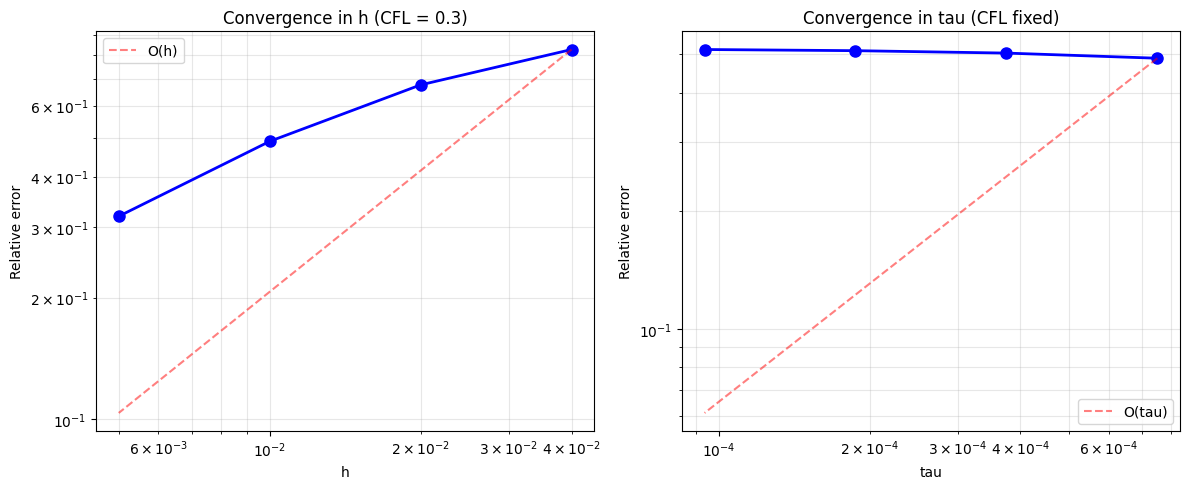

In [ ]:
errors_h, errors_tau = convergence_analysis(solve_upwind)

Решение задачи...
0.4
Вычисление точного решения...
Физическое время между кадрами: 0.0050 с
Интервал между кадрами: 2.5 мс
Всего кадров: 401
Длительность анимации: 2.00 с (физического времени задачи)
Длительность анимации: 1.00 с (реального времени)
Соотношение (реальное/физическое): 0.50
Сохранение анимации в transport.mp4...
Анимация сохранена!


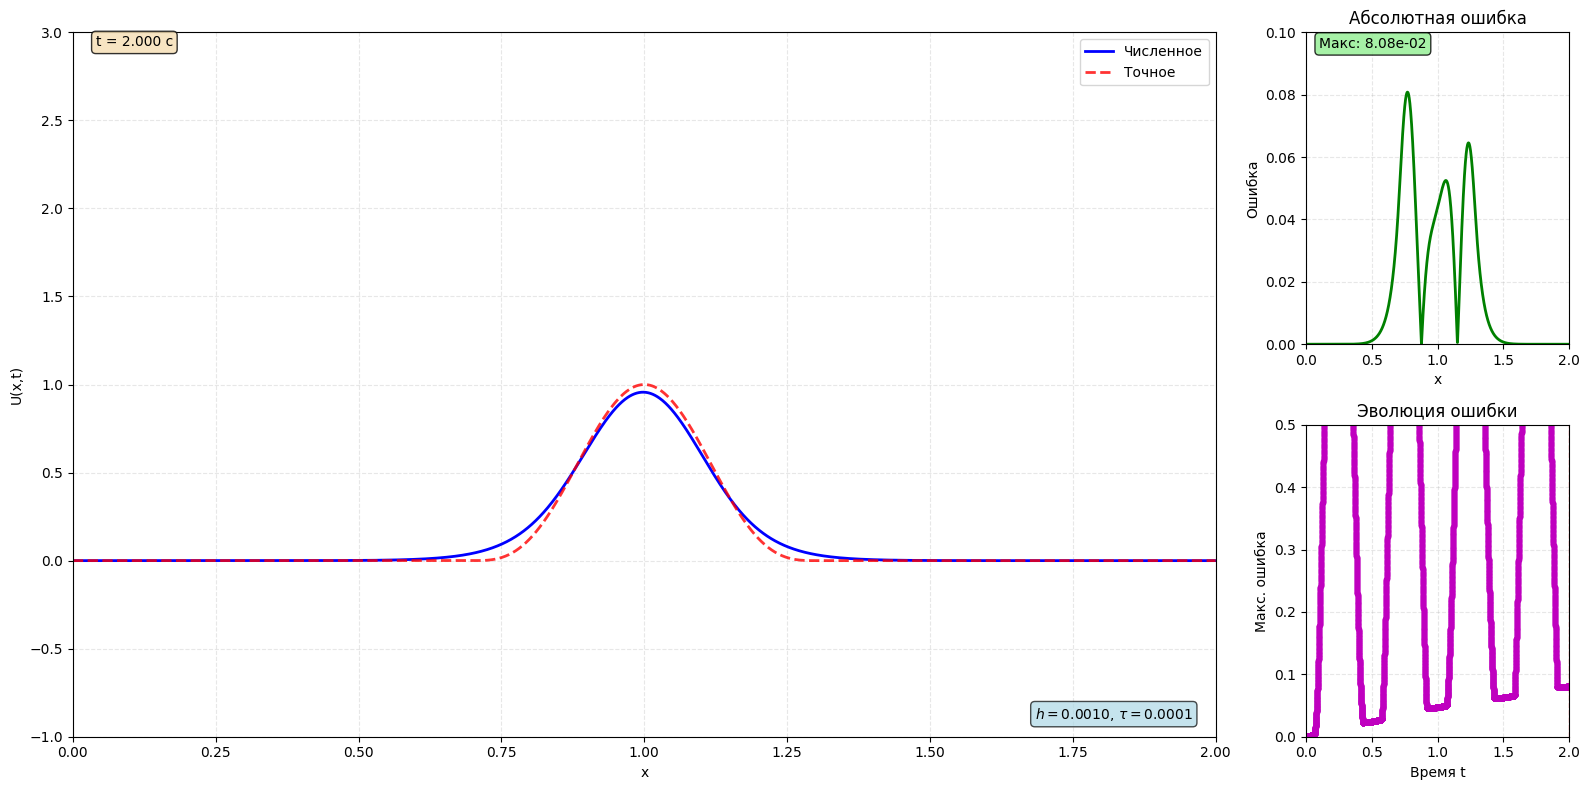

In [ ]:
h = 0.001
tau = 0.0001
anim = animate_solution(solve_upwind, filename="transport.mp4", frame_skip=50, speed_factor=0.5)